In [2]:
import sys, os, time
from pathlib import Path
import numpy as np
from PIL import Image
from IPython.display import display

In [3]:
sys.path.insert(0, "../")
from dataset import create_h5_episode_pathlengths_dataloader

/home/opervu-user/miniconda3/envs/nav_habitat07/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
h5_path= "/media/opervu-user/Data2/ws/data_langgeonet_e3d/e3d_metric_train_ep500.h5"
batch_size= 4
shuffle=False 
num_workers = 2

In [5]:
h5_path

'/media/opervu-user/Data2/ws/data_langgeonet_e3d/e3d_metric_train_ep500.h5'

In [6]:
dataloader= create_h5_episode_pathlengths_dataloader(h5_path,
                                                     batch_size)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [13]:
def overlay_costs(
    batch,
    idx,
    alpha=0.5,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from PIL import Image

    registry = batch['node_registries'][idx]
    img = np.asarray(batch['frame_rgbs'][idx]).astype(np.uint8)
    H, W = img.shape[:2]
    node_ids = list(registry.keys())
    masks = []
    costs = []

    # ── collect costs ────────────────────────────────────────────────────────
    raw_costs = []
    for node_id in node_ids:
        entry = registry[node_id]
        pr = np.asarray(entry.path_row, dtype=np.float64)
        cost = float(np.nanmean(pr)) if pr.size else np.nan
        raw_costs.append(cost)

        m = entry.mask
        try:
            m = m.cpu().numpy()
        except AttributeError:
            m = np.asarray(m)
        masks.append(m.astype(bool))

    # ── normalise costs to [0, 1] across all segments ────────────────────────
    finite = [c for c in raw_costs if np.isfinite(c)]
    c_min, c_max = (min(finite), max(finite)) if len(finite) > 1 else (0.0, 1.0)

    for c in raw_costs:
        if not np.isfinite(c):
            costs.append(np.nan)
        elif c_max == c_min:
            costs.append(0.0)
        else:
            costs.append((c - c_min) / (c_max - c_min))

    # ── green (0) → red (1) colormap ─────────────────────────────────────────
    cmap = mcolors.LinearSegmentedColormap.from_list(
        'green_red', ['#00cc44', '#ffff00', '#ff2200']   # green → yellow → red
    )

    overlay = img.astype(np.float32) / 255.0
    cost_canvas   = np.full((H, W), np.nan, dtype=np.float32)   # stores norm cost per px
    segment_mask  = np.zeros((H, W), dtype=bool)                # any segment present

    # ── paint each segment ───────────────────────────────────────────────────
    for m, cost in zip(masks, costs):
        # resize mask if needed
        if m.shape != (H, W):
            pil_m = Image.fromarray(m.astype(np.uint8) * 255)
            m = np.asarray(pil_m.resize((W, H), resample=Image.BILINEAR)) > 0

        if not m.any():
            continue

        cost_canvas[m] = 0.5 if np.isnan(cost) else cost   # grey→mid for unknowns
        segment_mask |= m

    # ── build RGBA heatmap layer and blend ───────────────────────────────────
    # normalised cost → RGBA colour for every pixel that belongs to a segment
    rgba_heat = np.zeros((H, W, 4), dtype=np.float32)
    if segment_mask.any():
        # fill unknown-cost pixels with 0.5 (yellow-ish) so they're visible
        canvas_filled = np.where(np.isnan(cost_canvas), 0.5, cost_canvas)
        rgba_heat[segment_mask] = cmap(canvas_filled[segment_mask])

    # blend: out = (1-alpha)*image + alpha*heatmap_rgb  (only inside segments)
    for c in range(3):
        overlay[segment_mask, c] = (
            (1 - alpha) * overlay[segment_mask, c]
            + alpha * rgba_heat[segment_mask, c]
        )

    # ── draw contours & cost labels ──────────────────────────────────────────
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    for m, cost in zip(masks, costs):
        if m.shape != (H, W):
            pil_m = Image.fromarray(m.astype(np.uint8) * 255)
            m = np.asarray(pil_m.resize((W, H), resample=Image.BILINEAR)) > 0

        if not m.any():
            continue

        # white contour
        pad = np.pad(m.astype(np.uint8), 1, mode='constant')
        neigh = pad[:-2,1:-1] + pad[2:,1:-1] + pad[1:-1,:-2] + pad[1:-1,2:]
        contour = m & (neigh < 4)
        overlay[contour] = 1.0

        # label at centroid
        ys, xs = np.where(m)
        cy, cx  = int(ys.mean()), int(xs.mean())
        label   = f"{cost:.2f}" if np.isfinite(cost) else "∞"
        ax.text(cx, cy, label, fontsize=7, color='white', ha='center', va='center',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.4, lw=0))

    ax.imshow(np.clip(overlay, 0, 1))

    # ── colorbar ─────────────────────────────────────────────────────────────
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Normalised cost  (0 = low / green,  1 = high / red)', fontsize=8)

    ax.set_title(f"ep={batch['episode_ids'][idx]}  frame={batch['frame_idxs'][idx]}")
    ax.axis('off')
    fig.tight_layout()
    return fig, overlay

In [52]:
import itertools

# Get the 5th batch (index 4)
batch_idx = 14
batch = next(itertools.islice(dataloader[0], batch_idx, None))

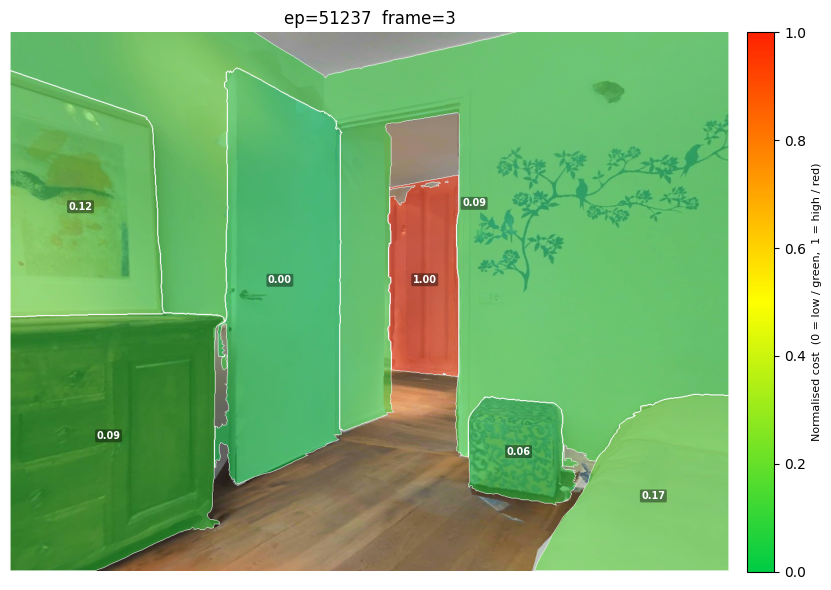

In [53]:
# display overlay for batch index 1 in the retrieved batch
fig, over = overlay_costs(batch, 3)


In [ ]:
fig